In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import gzip
import shutil
with gzip.open('data_3.4/RT.fits.gz', 'rb') as f_in:
    with open('data_3.4/RT.fits', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)
with gzip.open('data_th/Temperature.fits.gz', 'rb') as f_in:
    with open('data_th/Temperature.fits', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

Filename: data_3.4/RT.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      24   (30, 30, 1, 1, 1)   float32   
  1                1 ImageHDU        10   (1, 1, 1, 2)   float32   
  2                1 ImageHDU         9   (1, 1, 1)   float32   
  3                1 ImageHDU         8   (3, 1)   float32   
1.2533004e-12


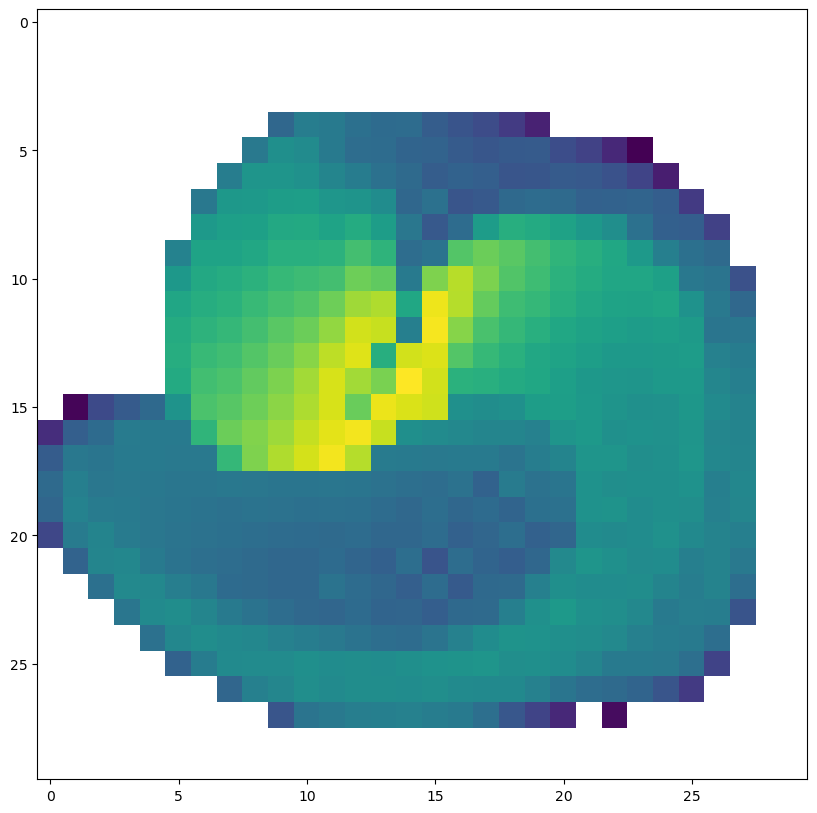

In [23]:
hdul = fits.open("data_3.4/RT.fits")
hdul.info()

data = hdul[0].data[0][0][0]

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(data[::-1, :], cmap='viridis', norm='log')

fig.savefig('image.png', dpi=400)

print(np.sum(data))

Filename: data_th/Temperature.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (3072,)   float32   


(array([  3.,   1.,  10.,  32.,  51.,  58., 134., 236., 171., 120.,  94.,
         89.,  74.,  60.,  64.,  55.,  57.,  54.,  52.,  54.,  66.,  53.,
         57.,  57.,  51.,  54.,  54.,  51.,  55.,  54.,  44.,  50.,  44.,
         45.,  46.,  35.,  43.,  36.,  40.,  40.,  27.,  31.,  40.,  35.,
         30.,  27.,  24.,  32.,  29.,  27.,  21.,  23.,  24.,  23.,  19.,
         22.,  18.,  21.,  17.,  23.,  17.,  17.,  32.,  35.,  12.,   1.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([217.84086609, 220.21136475, 222.5818634 , 224.95237732,
        227.32287598, 229.69337463, 232.06387329, 234.43437195,
        236.80487061, 239.17538452, 241.54588318, 243.91638184,
        246.28688049, 248.65737915, 251.02789307, 253.39839172,
        255.76889038, 258.1394043 , 260.5098877 , 262.88040161

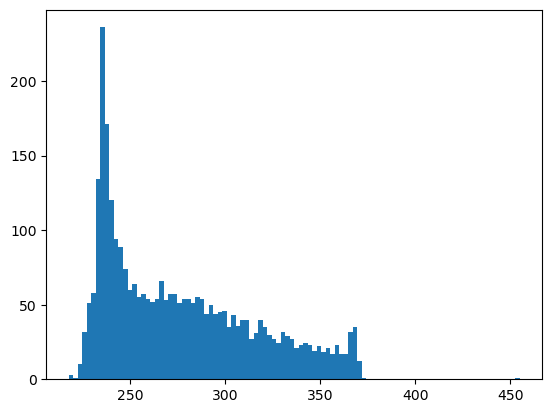

In [3]:

temps = fits.open("data_th/Temperature.fits")
temps.info()

temp_data = temps[0].data

fig, ax = plt.subplots()
ax.hist(temp_data, bins=100)

In [4]:
raw_densities = fits.open("apep1shell.fits")
raw_densities.info()

masses = raw_densities[0].data
weights = masses / max(masses)

particles = raw_densities[1].data
print(particles.shape)

Filename: apep1shell.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       5   (3074,)   float64   
  1                1 ImageHDU         7   (3, 3074)   float64   
(3074, 3)


/tmp/ipykernel_1944563/798996632.py:11: RuntimeWarning: invalid value encountered in divide
  H /= H_norm


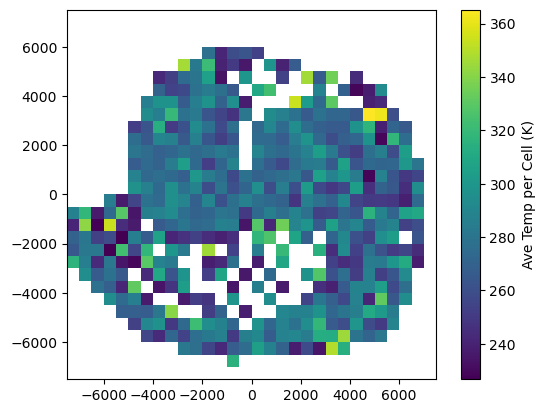

In [20]:
import numpy as np

resolution = hdul[0].data[0][0][0].shape[0]
indices = range(len(temp_data))
bound = np.max(np.abs(particles[indices, :2]))
pixels = np.linspace(-bound, bound, resolution + 1)

H, x, y = np.histogram2d(particles[indices, 0], particles[indices, 1], bins=pixels, weights=temp_data)
H_norm, x, y = np.histogram2d(particles[indices, 0], particles[indices, 1], bins=pixels)

H /= H_norm

fig, ax = plt.subplots()

# ax.scatter(particles[indices, 0], particles[indices, 1], c=temp_data, s=0.1)
# ax.set(aspect='equal')
p = ax.pcolormesh(x, y, H.T)
ax.set(aspect='equal')
fig.colorbar(p, label='Ave Temp per Cell (K)')

In [6]:
wcs

NameError: name 'wcs' is not defined